In [6]:
!pip install librosa

import os
import numpy as np
import pandas as pd
import librosa
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report, roc_curve
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Flatten, Conv1D, MaxPooling1D, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
import warnings
warnings.filterwarnings('ignore', category=UserWarning)

2026-06-13 12:44:54.041124: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1781354694.267486      58 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1781354694.330767      58 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1781354694.863044      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1781354694.863084      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1781354694.863087      58 computation_placer.cc:177] computation placer alr

In [7]:
def extract_features(file_path, max_pad_len=400):
    try:
        # Load audio file (resample to 16kHz)
        audio, sample_rate = librosa.load(file_path, sr=16000)
        
        # Extract MFCCs
        mfccs = librosa.feature.mfcc(y=audio, sr=sample_rate, n_mfcc=40)
        
        # Pad or truncate to ensure uniform shape
        if mfccs.shape[1] > max_pad_len:
            mfccs = mfccs[:, :max_pad_len]
        else:
            pad_width = max_pad_len - mfccs.shape[1]
            mfccs = np.pad(mfccs, pad_width=((0, 0), (0, pad_width)), mode='constant')
            
        return mfccs
    except Exception as e:
        print(f"Error processing {file_path}: {e}")
        return None

In [8]:
# Updated paths based on your Kaggle environment structure
# The for-norm dataset organizes data into 'real' and 'fake' folders, so we don't need a label.txt file.
BASE_TRAIN_PATH = "/kaggle/input/datasets/mohammedabdeldayem/the-fake-or-real-dataset/for-norm/for-norm/training"

# Fallback just in case the folder is named 'train' instead of 'training'
if not os.path.exists(BASE_TRAIN_PATH):
    BASE_TRAIN_PATH = "/kaggle/input/datasets/mohammedabdeldayem/the-fake-or-real-dataset/for-norm/for-norm/train"

def load_data(base_path, max_files_per_class=None):
    features = []
    labels = []
    
    # Encode: 0 for Genuine (real), 1 for Deepfake (fake)
    classes = {'real': 0, 'fake': 1}
    
    for class_name, label in classes.items():
        class_dir = os.path.join(base_path, class_name)
        
        if not os.path.exists(class_dir):
            print(f"Warning: Directory not found - {class_dir}")
            continue
            
        print(f"Loading '{class_name}' audio files from {class_dir}...")
        
        # Grab all .wav files in the directory
        valid_files = [f for f in os.listdir(class_dir) if f.endswith('.wav')]
        
        # Optional safeguard for Kaggle RAM limits
        if max_files_per_class:
            valid_files = valid_files[:max_files_per_class]
            
        for count, file_name in enumerate(valid_files):
            file_path = os.path.join(class_dir, file_name)
            
            # extract_features is called from Cell 2
            mfccs = extract_features(file_path) 
            
            if mfccs is not None:
                features.append(mfccs)
                labels.append(label)
                
            if (count + 1) % 500 == 0:
                print(f"Processed {count + 1} {class_name} files...")
                
    return np.array(features), np.array(labels)

print("Extracting features... This will take some time.")
# Load the data directly from the folders
X, y = load_data(BASE_TRAIN_PATH)

# Reshape data for CNN (Samples, Timesteps, Features)
X = X.reshape(X.shape[0], X.shape[1], X.shape[2]) 
# Transpose to shape (Samples, max_pad_len, n_mfcc) for Conv1D
X = np.transpose(X, (0, 2, 1))

# Split the dataset (80% training, 20% validation)
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f"Training shapes: X={X_train.shape}, y={y_train.shape}")

Extracting features... This will take some time.
Loading 'real' audio files from /kaggle/input/datasets/mohammedabdeldayem/the-fake-or-real-dataset/for-norm/for-norm/training/real...
Processed 500 real files...
Processed 1000 real files...
Processed 1500 real files...
Processed 2000 real files...
Processed 2500 real files...
Processed 3000 real files...
Processed 3500 real files...
Processed 4000 real files...
Processed 4500 real files...
Processed 5000 real files...
Processed 5500 real files...
Processed 6000 real files...
Processed 6500 real files...
Processed 7000 real files...
Processed 7500 real files...
Processed 8000 real files...
Processed 8500 real files...
Processed 9000 real files...
Processed 9500 real files...
Processed 10000 real files...
Processed 10500 real files...
Processed 11000 real files...
Processed 11500 real files...
Processed 12000 real files...
Processed 12500 real files...
Processed 13000 real files...
Processed 13500 real files...
Processed 14000 real files.

In [9]:
model = Sequential([
    Conv1D(64, kernel_size=3, activation='relu', input_shape=(X_train.shape[1], X_train.shape[2])),
    BatchNormalization(),
    MaxPooling1D(pool_size=2),
    Dropout(0.3),
    
    Conv1D(128, kernel_size=3, activation='relu'),
    BatchNormalization(),
    MaxPooling1D(pool_size=2),
    Dropout(0.3),
    
    Conv1D(256, kernel_size=3, activation='relu'),
    BatchNormalization(),
    MaxPooling1D(pool_size=2),
    Dropout(0.3),
    
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.4),
    Dense(1, activation='sigmoid') # Binary classification
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model.summary()

I0000 00:00:1781355569.202970      58 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1781355569.208602      58 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 398, 64)        │         7,744 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 398, 64)        │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 199, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 199, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 197, 128)       │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 197, 128)       │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 98, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 98, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 96, 256)        │        98,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 96, 256)        │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_2 (MaxPooling1D)  │ (None, 48, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 48, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 12288)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     1,572,992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,705,921 (6.51 MB)

 Trainable params: 1,705,025 (6.50 MB)

 Non-trainable params: 896 (3.50 KB)

In [10]:
# Save the best model automatically
checkpoint = ModelCheckpoint('deepfake_audio_model.keras', save_best_only=True, monitor='val_accuracy', mode='max')
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

history = model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=32,
    validation_data=(X_val, y_val),
    callbacks=[checkpoint, early_stopping]
)

Epoch 1/50


I0000 00:00:1781355579.677005     201 service.cc:152] XLA service 0x7b6b780031c0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1781355579.677041     201 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1781355579.677045     201 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1781355580.340143     201 cuda_dnn.cc:529] Loaded cuDNN version 91002
2026-06-13 12:59:42.479842: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-13 12:59:42.719207: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


  19/1347 ━━━━━━━━━━━━━━━━━━━━ 12s 9ms/step - accuracy: 0.7211 - loss: 1.7362  

I0000 00:00:1781355587.084147     201 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


1347/1347 ━━━━━━━━━━━━━━━━━━━━ 27s 13ms/step - accuracy: 0.9547 - loss: 0.1387 - val_accuracy: 0.9899 - val_loss: 0.0304
Epoch 2/50
1347/1347 ━━━━━━━━━━━━━━━━━━━━ 9s 7ms/step - accuracy: 0.9878 - loss: 0.0377 - val_accuracy: 0.9788 - val_loss: 0.0803
Epoch 3/50
1347/1347 ━━━━━━━━━━━━━━━━━━━━ 9s 7ms/step - accuracy: 0.9900 - loss: 0.0314 - val_accuracy: 0.9924 - val_loss: 0.0217
Epoch 4/50
1347/1347 ━━━━━━━━━━━━━━━━━━━━ 9s 7ms/step - accuracy: 0.9933 - loss: 0.0240 - val_accuracy: 0.9954 - val_loss: 0.0128
Epoch 5/50
1347/1347 ━━━━━━━━━━━━━━━━━━━━ 9s 7ms/step - accuracy: 0.9933 - loss: 0.0220 - val_accuracy: 0.9971 - val_loss: 0.0089
Epoch 6/50
1347/1347 ━━━━━━━━━━━━━━━━━━━━ 9s 7ms/step - accuracy: 0.9938 - loss: 0.0213 - val_accuracy: 0.9978 - val_loss: 0.0069
Epoch 7/50
1347/1347 ━━━━━━━━━━━━━━━━━━━━ 9s 7ms/step - accuracy: 0.9950 - loss: 0.0165 - val_accuracy: 0.9968 - val_loss: 0.0111
Epoch 8/50
1347/1347 ━━━━━━━━━━━━━━━━━━━━ 9s 7ms/step - accuracy: 0.9955 - loss: 0.0147 - val_accur

337/337 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step
Overall Accuracy: 99.86%
F1 Score: 99.86%
Genuine Accuracy: 99.78%
Deepfake Accuracy: 99.94%


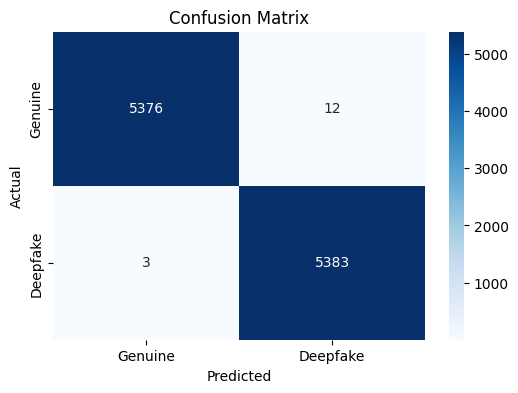

Equal Error Rate (EER): 0.13%


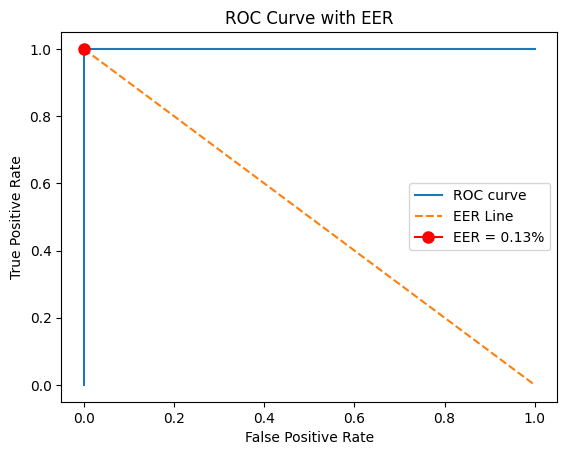

In [11]:
# Generate Predictions
y_pred_probs = model.predict(X_val).flatten()
y_pred_classes = (y_pred_probs > 0.5).astype(int)

# 1. Overall Accuracy & F1 Score
accuracy = accuracy_score(y_val, y_pred_classes)
f1 = f1_score(y_val, y_pred_classes)

print(f"Overall Accuracy: {accuracy * 100:.2f}%")
print(f"F1 Score: {f1 * 100:.2f}%")

# 2. Confusion Matrix & Per-Class Accuracy
cm = confusion_matrix(y_val, y_pred_classes)
genuine_acc = cm[0,0] / (cm[0,0] + cm[0,1])
fake_acc = cm[1,1] / (cm[1,0] + cm[1,1])

print(f"Genuine Accuracy: {genuine_acc * 100:.2f}%")
print(f"Deepfake Accuracy: {fake_acc * 100:.2f}%")

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Genuine', 'Deepfake'], yticklabels=['Genuine', 'Deepfake'])
plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

# 3. Equal Error Rate (EER) Calculation
fpr, tpr, thresholds = roc_curve(y_val, y_pred_probs)
fnr = 1 - tpr

# EER is the point where False Positive Rate == False Negative Rate
eer_index = np.nanargmin(np.absolute((fnr - fpr)))
eer = fpr[eer_index]
print(f"Equal Error Rate (EER): {eer * 100:.2f}%")

# Optional: Plot the ROC and EER point
plt.figure()
plt.plot(fpr, tpr, label='ROC curve')
plt.plot([0, 1], [1, 0], linestyle='--', label='EER Line')
plt.plot(fpr[eer_index], tpr[eer_index], marker='o', markersize=8, color="red", label=f'EER = {eer*100:.2f}%')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve with EER')
plt.legend()
plt.show()

In [12]:
# Save the final trained model
model_filename = 'deepfake_audio_model.keras'
model.save(model_filename)

print(f"Model successfully saved as {model_filename} in the current working directory.")

# Optional: Verify the file exists in Kaggle's working directory
import os
if os.path.exists(model_filename):
    print(f"File size: {os.path.getsize(model_filename) / (1024 * 1024):.2f} MB")

Model successfully saved as deepfake_audio_model.keras in the current working directory.
File size: 19.58 MB
